# Machine Learning - Chapter 3
# Data Preprocessing & Feature Engineering

## What is Data Preprocessing?

Data preprocessing is the process of cleaning and transforming raw data into a format suitable for Machine Learning.

### Why is it Needed?

Real-world data often contains:

- Missing values
- Duplicate records
- Incorrect data
- Noise
- Outliers
- Different scales

Without preprocessing, machine learning models perform poorly.

## Data Preprocessing Pipeline

```text
Raw Data
    ↓
Data Cleaning
    ↓
Handle Missing Values
    ↓
Encoding
    ↓
Feature Scaling
    ↓
Feature Selection
    ↓
Train-Test Split
    ↓
ML Model
```

# Dataset Example

Consider the following employee dataset:

| Age | Salary | Gender | Purchased |
|------|---------|---------|------------|
| 25 | 50000 | Male | Yes |
| 30 | 60000 | Female | No |
| NaN | 55000 | Male | Yes |
| 35 | NaN | Female | No |

Problems:

- Missing Age
- Missing Salary
- Categorical Variables
- Different Scales

These issues must be fixed before training.

# 1. Handling Missing Values

Missing values are common in datasets.

Examples:

- Empty cells
- NULL values
- NaN values

## Methods

### Remove Rows

Useful when only a few rows contain missing values.

### Remove Columns

Useful when an entire column contains many missing values.

### Fill Missing Values

Replace missing values with:

- Mean
- Median
- Mode
- Constant Value

In [1]:
import pandas as pd
import numpy as np

data = {
    "Age":[25,30,np.nan,35],
    "Salary":[50000,60000,55000,np.nan]
}

df = pd.DataFrame(data)

print(df)

    Age   Salary
0  25.0  50000.0
1  30.0  60000.0
2   NaN  55000.0
3  35.0      NaN


In [2]:
# Fill missing values with mean

df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

print(df)

    Age   Salary
0  25.0  50000.0
1  30.0  60000.0
2  30.0  55000.0
3  35.0  55000.0


# Mean vs Median vs Mode

## Mean

Average value.

Best when data is normally distributed.

## Median

Middle value.

Best when outliers exist.

## Mode

Most frequent value.

Used mainly for categorical data.

# 2. Removing Duplicate Data

Duplicate records can affect model performance.

Example:

| ID | Name |
|----|------|
| 1 | John |
| 1 | John |

Duplicates should usually be removed.

In [3]:
import pandas as pd

data = {
    "Name":["John","John","Alice"],
    "Age":[25,25,30]
}

df = pd.DataFrame(data)

print("Before:")
print(df)

df = df.drop_duplicates()

print("\nAfter:")
print(df)

Before:
    Name  Age
0   John   25
1   John   25
2  Alice   30

After:
    Name  Age
0   John   25
2  Alice   30


# 3. Encoding Categorical Data

Machine Learning algorithms work with numbers.

Text data must be converted into numerical form.

Example:

Gender

Male
Female

Cannot be directly processed.

# Label Encoding

Converts categories into numbers.

Example:

Male → 1

Female → 0

In [4]:
from sklearn.preprocessing import LabelEncoder

gender = ["Male","Female","Male","Female"]

encoder = LabelEncoder()

encoded = encoder.fit_transform(gender)

print(encoded)

[1 0 1 0]


# One-Hot Encoding

Creates separate columns for each category.

### Example

**Gender**

| Gender |
|---------|
| Male |
| Female |

becomes

| Male | Female |
|------|--------|
| 1 | 0 |
| 0 | 1 |

In [5]:
import pandas as pd

df = pd.DataFrame({
    "Gender":["Male","Female","Male"]
})

encoded = pd.get_dummies(df)

print(encoded)

   Gender_Female  Gender_Male
0          False         True
1           True        False
2          False         True


# 4. Feature Scaling

Different features often have different ranges.

Example:

Age = 25

Salary = 50000

Salary dominates Age.

Feature scaling solves this problem.

# Why Scaling is Important?

Algorithms affected by scaling:

- KNN
- K-Means
- SVM
- Neural Networks
- PCA

Algorithms less affected:

- Decision Trees
- Random Forest

# Normalization

Scales values between 0 and 1.

Formula:

X' = (X - Xmin) / (Xmax - Xmin)

Range:

0 to 1

In [6]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

data = [[25],[30],[35],[40]]

scaler = MinMaxScaler()

scaled = scaler.fit_transform(data)

print(scaled)

[[0.        ]
 [0.33333333]
 [0.66666667]
 [1.        ]]


# Standardization

Transforms data so that:

Mean = 0

Standard Deviation = 1

Formula:

Z = (X - Mean) / Standard Deviation

In [7]:
from sklearn.preprocessing import StandardScaler

data = [[25],[30],[35],[40]]

scaler = StandardScaler()

scaled = scaler.fit_transform(data)

print(scaled)

[[-1.34164079]
 [-0.4472136 ]
 [ 0.4472136 ]
 [ 1.34164079]]


# Normalization vs Standardization

| Normalization | Standardization |
|--------------|----------------|
| Range 0-1 | Mean 0 |
| Sensitive to Outliers | Better with Outliers |
| MinMaxScaler | StandardScaler |

# 5. Outlier Detection

Outliers are extreme values.

Example:

10, 12, 15, 13, 14, 500

500 is an outlier.

Problems:

- Distorts statistics
- Reduces model accuracy

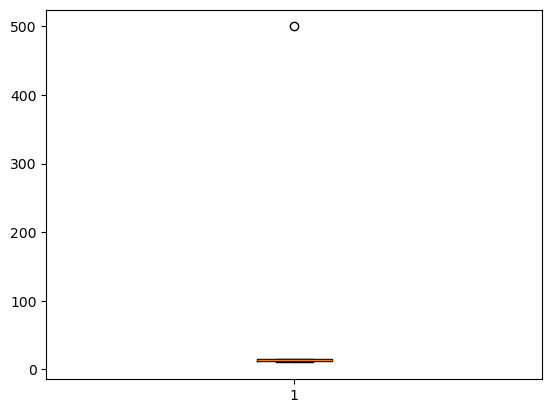

In [8]:
import matplotlib.pyplot as plt

data = [10,12,15,13,14,500]

plt.boxplot(data)

plt.show()

# 6. Feature Selection

Feature Selection means selecting the most important features.

Example:

House Price Prediction

Features:

- Area
- Bedrooms
- Location
- Owner Name

Owner Name may not help prediction.

Remove irrelevant features.

# Benefits of Feature Selection

- Faster Training
- Less Memory Usage
- Better Accuracy
- Reduced Overfitting

# Feature Extraction

Feature Extraction creates new useful features.

Example:

Date

2025-06-20

Extract:

- Day
- Month
- Year
- Weekday

These become new features.

In [10]:
import pandas as pd

df = pd.DataFrame({
    "Date":["2025-06-20"]
})

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

print(df)

        Date  Year  Month  Day
0 2025-06-20  2025      6   20


# 7. Train-Test Split

We must evaluate the model on unseen data.

Common split:

80% Training

20% Testing

In [11]:
from sklearn.model_selection import train_test_split

X = [[1],[2],[3],[4],[5]]
y = [10,20,30,40,50]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:",X_train)
print("Testing:",X_test)

Training: [[5], [3], [1], [4]]
Testing: [[2]]


# Complete Preprocessing Workflow

```text
Collect Data
      ↓
Handle Missing Values
      ↓
Remove Duplicates
      ↓
Encode Categories
      ↓
Scale Features
      ↓
Handle Outliers
      ↓
Feature Selection
      ↓
Train-Test Split
      ↓
Model Training
```

# Real-World Example

House Price Prediction

Raw Features:

- Area
- Bedrooms
- City
- Owner Name
- Date Listed

Preprocessing:

1. Fill Missing Values
2. Encode City
3. Scale Area
4. Remove Outliers
5. Extract Year from Date
6. Train-Test Split

Result:

Clean dataset ready for Machine Learning.

# Summary

Data preprocessing is the foundation of Machine Learning.

Important Steps:

1. Handle Missing Values
2. Remove Duplicates
3. Encode Categorical Data
4. Scale Features
5. Detect Outliers
6. Select Features
7. Extract Features
8. Train-Test Split

A good preprocessing pipeline often improves performance more than changing algorithms.

# Interview & Exam Questions

1. What is data preprocessing?
2. Why is preprocessing important?
3. What are missing values?
4. Explain mean, median and mode imputation.
5. What is label encoding?
6. What is one-hot encoding?
7. Difference between normalization and standardization.
8. What are outliers?
9. Why is feature scaling important?
10. What is feature selection?
11. What is feature extraction?
12. What is train-test split?
13. Which algorithms require scaling?
14. How do you handle duplicate data?
15. Explain the complete preprocessing workflow.